<a href="https://colab.research.google.com/github/jitendra931/Banking-system/blob/main/IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDB Movie Reviews Sentiment Analysis

## Project Overview
This notebook performs comprehensive sentiment analysis on IMDB movie reviews. We'll explore the dataset, preprocess the text data, apply multiple sentiment analysis techniques, and visualize the results.

## Table of Contents
1. [Environment Setup]
2. [Data Loading and Exploration]
3. [Data Preprocessing]
4. [Sentiment Analysis](#analysis)
5. [Results Visualization](#visualization)
6. [Model Comparison](#comparison)
7. [Export Results](#export)

---


In [45]:
# Install required packages
!pip install pandas numpy matplotlib seaborn textblob vaderSentiment nltk scikit-learn TextBlob wordcloud --quiet

# Download required NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("✓ All packages installed successfully!")

✓ All packages installed successfully!


In [46]:
# Import libraries
import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime

# Natural Language Processing
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully!")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✓ All libraries imported successfully!
Analysis started at: 2026-04-11 06:26:36


In [47]:
# Load the dataset
# Adjust the file path as needed
file_path = '/content/IMDB datasets.xlsx'

try:
    df = pd.read_excel('/content/IMDB datasets.xlsx')
    print("✓ Dataset loaded successfully!")
    print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("❌ Error: File not found. Please check the file path.")
    raise
except Exception as e:
    print(f"❌ Error loading dataset: {str(e)}")
    raise

✓ Dataset loaded successfully!

Dataset shape: 50,000 rows × 2 columns


In [48]:
# Display basic information about the dataset
print("Dataset Information:")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("Column Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Column Names:
['review', 'sentiment']


In [50]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [52]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percentage
})

print(missing_df)

if missing_data.sum() == 0:
    print("\n✓ No missing values found!")
else:
    print(f"\n⚠ Total missing values: {missing_data.sum()}")


Missing Values Analysis:
           Missing Count  Percentage
review                 0         0.0
sentiment              0         0.0

✓ No missing values found!


In [53]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [54]:
# Analyze review text statistics
print("Review Text Statistics:")
print("=" * 50)

# Calculate review lengths
df['review_length'] = df['review'].astype(str).apply(len)
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

print(f"Average review length (characters): {df['review_length'].mean():.0f}")
print(f"Average word count: {df['word_count'].mean():.0f}")
print(f"Shortest review: {df['review_length'].min()} characters")
print(f"Longest review: {df['review_length'].max()} characters")

# Display distribution statistics
print("\nReview Length Distribution:")
print(df['review_length'].describe())

Review Text Statistics:
Average review length (characters): 1309
Average word count: 231
Shortest review: 7 characters
Longest review: 13704 characters

Review Length Distribution:
count    50000.000000
mean      1309.368320
std        989.760785
min          7.000000
25%        699.000000
50%        970.000000
75%       1590.000000
max      13704.000000
Name: review_length, dtype: float64


Existing Sentiment Label Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Total unique sentiments: 2


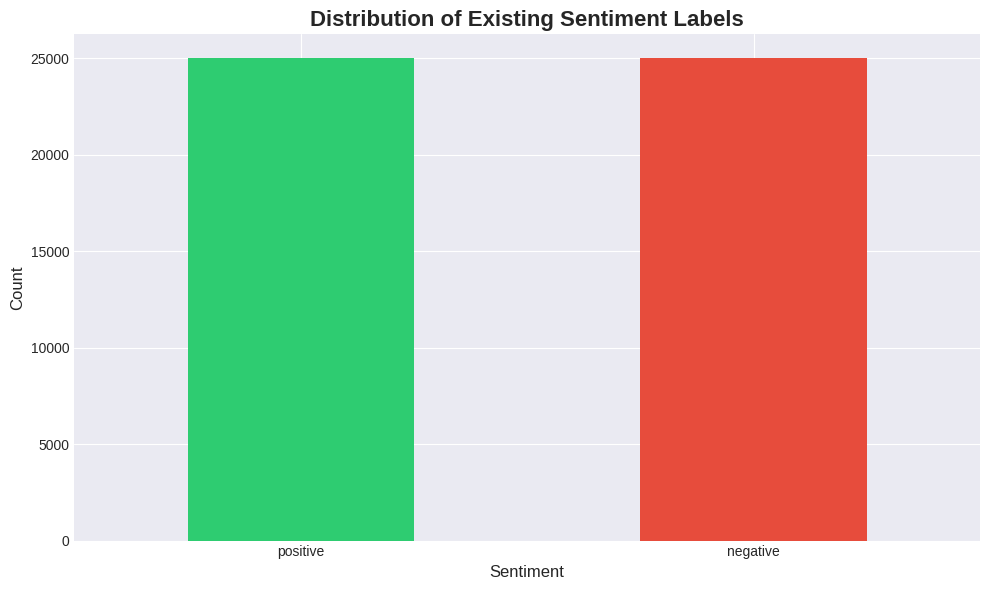

In [55]:
# Check if dataset has existing sentiment labels
if 'sentiment' in df.columns:
    print("Existing Sentiment Label Distribution:")
    print("=" * 50)
    sentiment_dist = df['sentiment'].value_counts()
    print(sentiment_dist)
    print(f"\nTotal unique sentiments: {df['sentiment'].nunique()}")

    # Visualize distribution
    plt.figure(figsize=(10, 6))
    sentiment_dist.plot(kind='bar', color=['#2ecc71', '#e74c3c', '#f39c12'])
    plt.title('Distribution of Existing Sentiment Labels', fontsize=16, fontweight='bold')
    plt.xlabel('Sentiment', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No existing sentiment labels found in the dataset.")


Existing Sentiment Label Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Total unique sentiments: 2


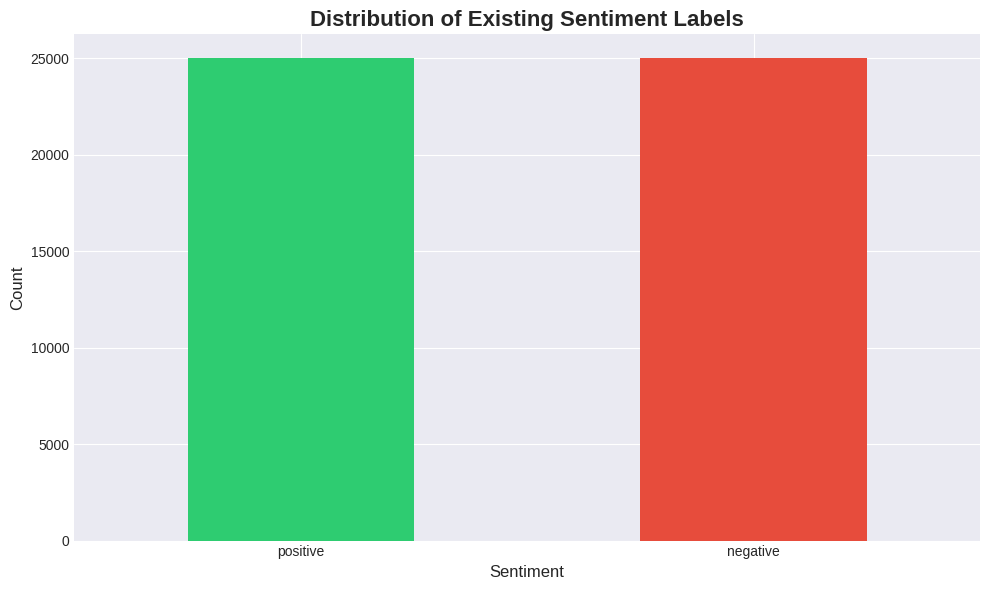

In [56]:
# Check if dataset has existing sentiment labels
if 'sentiment' in df.columns:
    print("Existing Sentiment Label Distribution:")
    print("=" * 50)
    sentiment_dist = df['sentiment'].value_counts()
    print(sentiment_dist)
    print(f"\nTotal unique sentiments: {df['sentiment'].nunique()}")

    # Visualize distribution
    plt.figure(figsize=(10, 6))
    sentiment_dist.plot(kind='bar', color=['#2ecc71', '#e74c3c', '#f39c12'])
    plt.title('Distribution of Existing Sentiment Labels', fontsize=16, fontweight='bold')
    plt.xlabel('Sentiment', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No existing sentiment labels found in the dataset.")


In [57]:
def clean_text(text):
    """
    Clean and preprocess text data.

    Parameters:
    -----------
    text : str
        Raw text to be cleaned

    Returns:
    --------
    str : Cleaned text
    """
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove special characters but keep basic punctuation for sentiment
    text = re.sub(r'[^a-zA-Z0-9\s.!?,\'\-]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning to the review column
print("Cleaning text data...")
df['cleaned_review'] = df['review'].apply(clean_text)

print("✓ Text cleaning completed!")
print(f"\nSample of cleaned reviews:")
print("=" * 50)
for i in range(3):
    print(f"\nOriginal [{i+1}]:\n{df['review'].iloc[i][:200]}...")
    print(f"\nCleaned [{i+1}]:\n{df['cleaned_review'].iloc[i][:200]}...")
    print("-" * 50)

Cleaning text data...
✓ Text cleaning completed!

Sample of cleaned reviews:

Original [1]:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Cleaned [1]:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was i...
--------------------------------------------------

Original [2]:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...

Cleaned [2]:
A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors..

In [58]:
def get_vader_sentiment(text):
    """
    Analyze sentiment using VADER.

    Parameters:
    -----------
    text : str
        Text to analyze

    Returns:
    --------
    tuple : (sentiment_label, compound_score)
    """
    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']

    # Classify based on compound score
    if compound >= 0.05:
        return 'positive', compound
    elif compound <= -0.05:
        return 'negative', compound
    else:
        return 'neutral', compound

# Apply VADER sentiment analysis
print("Performing VADER sentiment analysis...")
print("This may take a few minutes for large datasets...")

vader_results = df['cleaned_review'].apply(get_vader_sentiment)
df['vader_sentiment'] = vader_results.apply(lambda x: x[0])
df['vader_score'] = vader_results.apply(lambda x: x[1])

print("✓ VADER analysis completed!")

# Display results
print("\nVADER Sentiment Distribution:")
print("=" * 50)
print(df['vader_sentiment'].value_counts())
print(f"\nVADER Score Statistics:")
print(df['vader_score'].describe())


Performing VADER sentiment analysis...
This may take a few minutes for large datasets...
✓ VADER analysis completed!

VADER Sentiment Distribution:
vader_sentiment
positive    33030
negative    16645
neutral       325
Name: count, dtype: int64

VADER Score Statistics:
count    50000.000000
mean         0.307434
std          0.806837
min         -0.999700
25%         -0.684700
50%          0.833700
75%          0.972700
max          0.999900
Name: vader_score, dtype: float64


In [59]:
def get_textblob_sentiment(text):
    """
    Analyze sentiment using TextBlob.

    Parameters:
    -----------
    text : str
        Text to analyze

    Returns:
    --------
    tuple : (sentiment_label, polarity_score)
    """
    try:
        blob = TextBlob(text)
        polarity = blob.sentiment.polarity

        # Classify based on polarity
        if polarity > 0.05:
            return 'positive', polarity
        elif polarity < -0.05:
            return 'negative', polarity
        else:
            return 'neutral', polarity
    except:
        return 'neutral', 0.0

# Apply TextBlob sentiment analysis
print("Performing TextBlob sentiment analysis...")
print("This may take a few minutes for large datasets...")

textblob_results = df['cleaned_review'].apply(get_textblob_sentiment)
df['textblob_sentiment'] = textblob_results.apply(lambda x: x[0])
df['textblob_score'] = textblob_results.apply(lambda x: x[1])

print("✓ TextBlob analysis completed!")

# Display results
print("\nTextBlob Sentiment Distribution:")
print("=" * 50)
print(df['textblob_sentiment'].value_counts())
print(f"\nTextBlob Score Statistics:")
print(df['textblob_score'].describe())

Performing TextBlob sentiment analysis...
This may take a few minutes for large datasets...
✓ TextBlob analysis completed!

TextBlob Sentiment Distribution:
textblob_sentiment
positive    32137
neutral     10069
negative     7794
Name: count, dtype: int64

TextBlob Score Statistics:
count    50000.000000
mean         0.102680
std          0.163746
min         -1.000000
25%          0.002976
50%          0.103828
75%          0.202890
max          1.000000
Name: textblob_score, dtype: float64


In [60]:
def get_ensemble_sentiment(vader_sent, textblob_sent, vader_score, textblob_score):
    """
    Combine VADER and TextBlob predictions for ensemble sentiment.
    Uses voting mechanism with score averaging as tiebreaker.
    """
    if vader_sent == textblob_sent:
        return vader_sent
    else:
        # Use average score as tiebreaker
        avg_score = (vader_score + textblob_score) / 2
        if avg_score > 0.05:
            return 'positive'
        elif avg_score < -0.05:
            return 'negative'
        else:
            return 'neutral'

# Create ensemble sentiment
df['ensemble_sentiment'] = df.apply(
    lambda row: get_ensemble_sentiment(
        row['vader_sentiment'],
        row['textblob_sentiment'],
        row['vader_score'],
        row['textblob_score']
    ),
    axis=1
)

print("Ensemble Sentiment Distribution:")
print("=" * 50)
print(df['ensemble_sentiment'].value_counts())

Ensemble Sentiment Distribution:
ensemble_sentiment
positive    32985
negative    16200
neutral       815
Name: count, dtype: int64


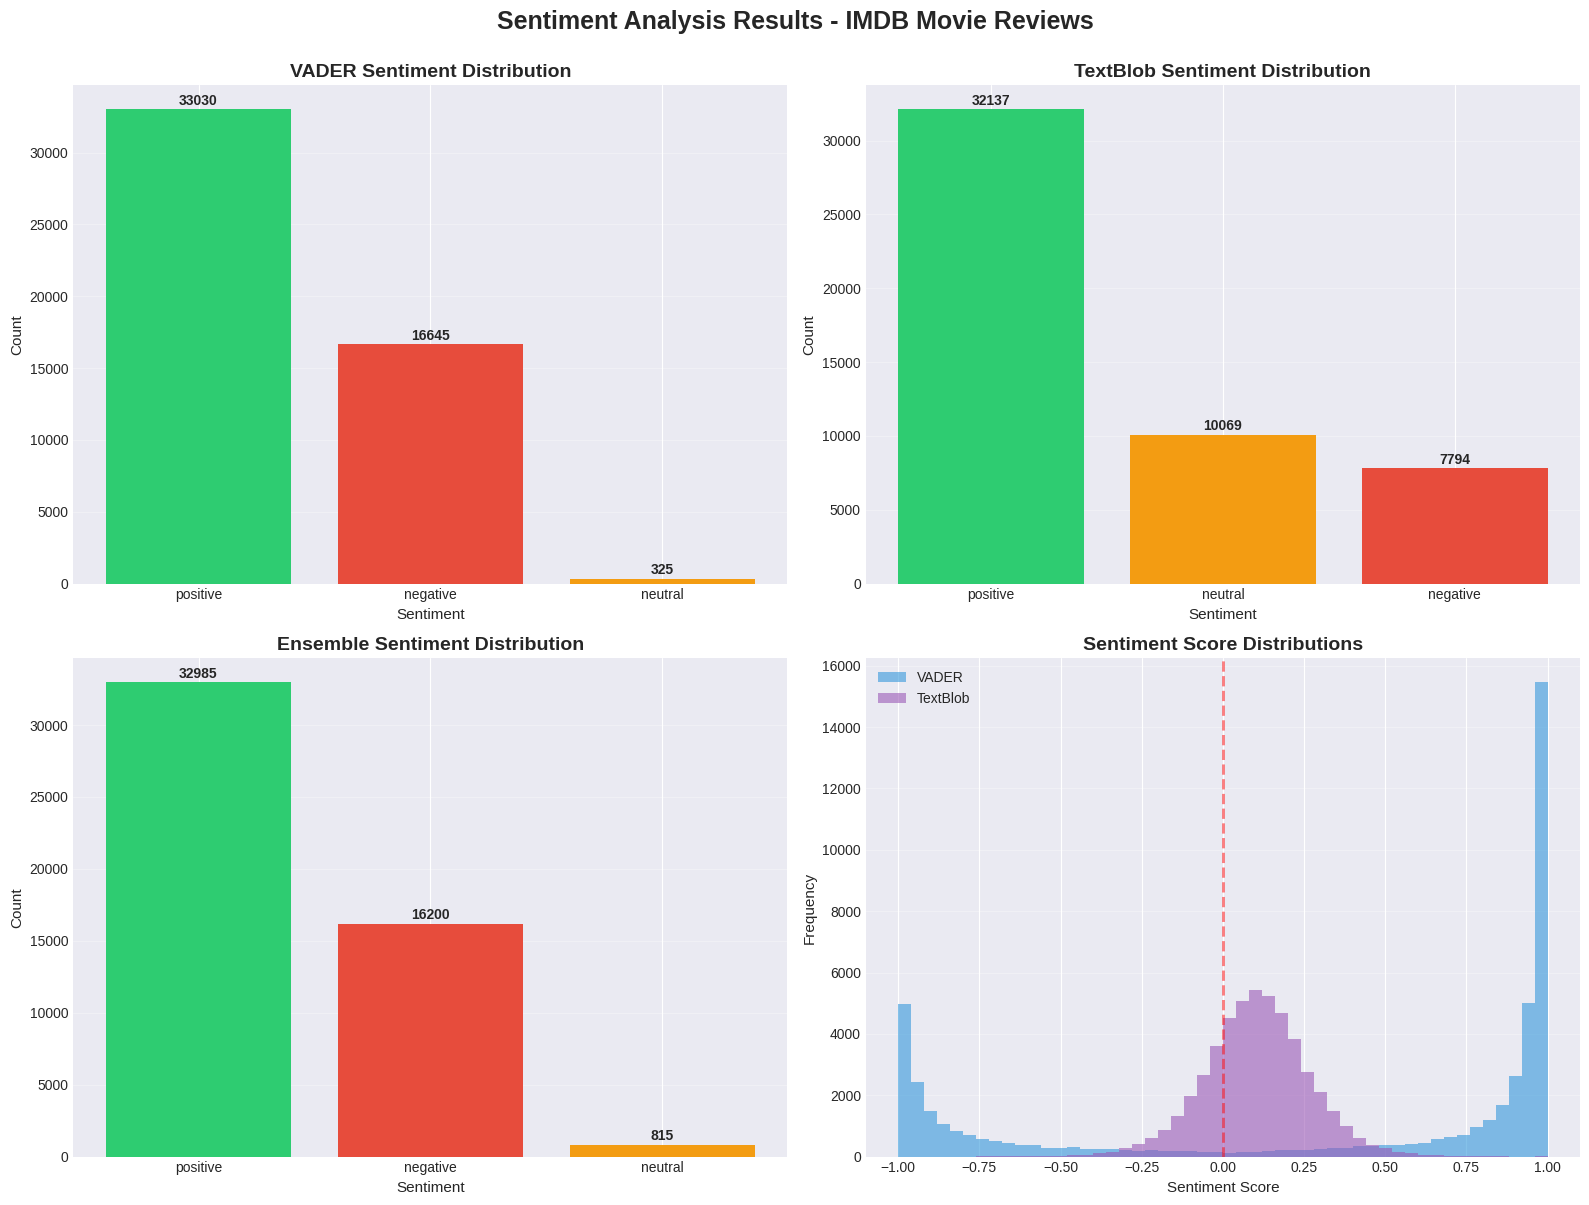

In [61]:
# Set up color palette
sentiment_colors = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#f39c12'}

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sentiment Analysis Results - IMDB Movie Reviews', fontsize=18, fontweight='bold', y=1.00)

# Plot 1: VADER Sentiment Distribution
vader_counts = df['vader_sentiment'].value_counts()
axes[0, 0].bar(vader_counts.index, vader_counts.values,
               color=[sentiment_colors.get(x, '#95a5a6') for x in vader_counts.index])
axes[0, 0].set_title('VADER Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sentiment', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(vader_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: TextBlob Sentiment Distribution
textblob_counts = df['textblob_sentiment'].value_counts()
axes[0, 1].bar(textblob_counts.index, textblob_counts.values,
               color=[sentiment_colors.get(x, '#95a5a6') for x in textblob_counts.index])
axes[0, 1].set_title('TextBlob Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Sentiment', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(textblob_counts.values):
    axes[0, 1].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 3: Ensemble Sentiment Distribution
ensemble_counts = df['ensemble_sentiment'].value_counts()
axes[1, 0].bar(ensemble_counts.index, ensemble_counts.values,
               color=[sentiment_colors.get(x, '#95a5a6') for x in ensemble_counts.index])
axes[1, 0].set_title('Ensemble Sentiment Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(ensemble_counts.values):
    axes[1, 0].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 4: Sentiment Score Distributions
axes[1, 1].hist(df['vader_score'], bins=50, alpha=0.6, label='VADER', color='#3498db')
axes[1, 1].hist(df['textblob_score'], bins=50, alpha=0.6, label='TextBlob', color='#9b59b6')
axes[1, 1].set_title('Sentiment Score Distributions', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment Score', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

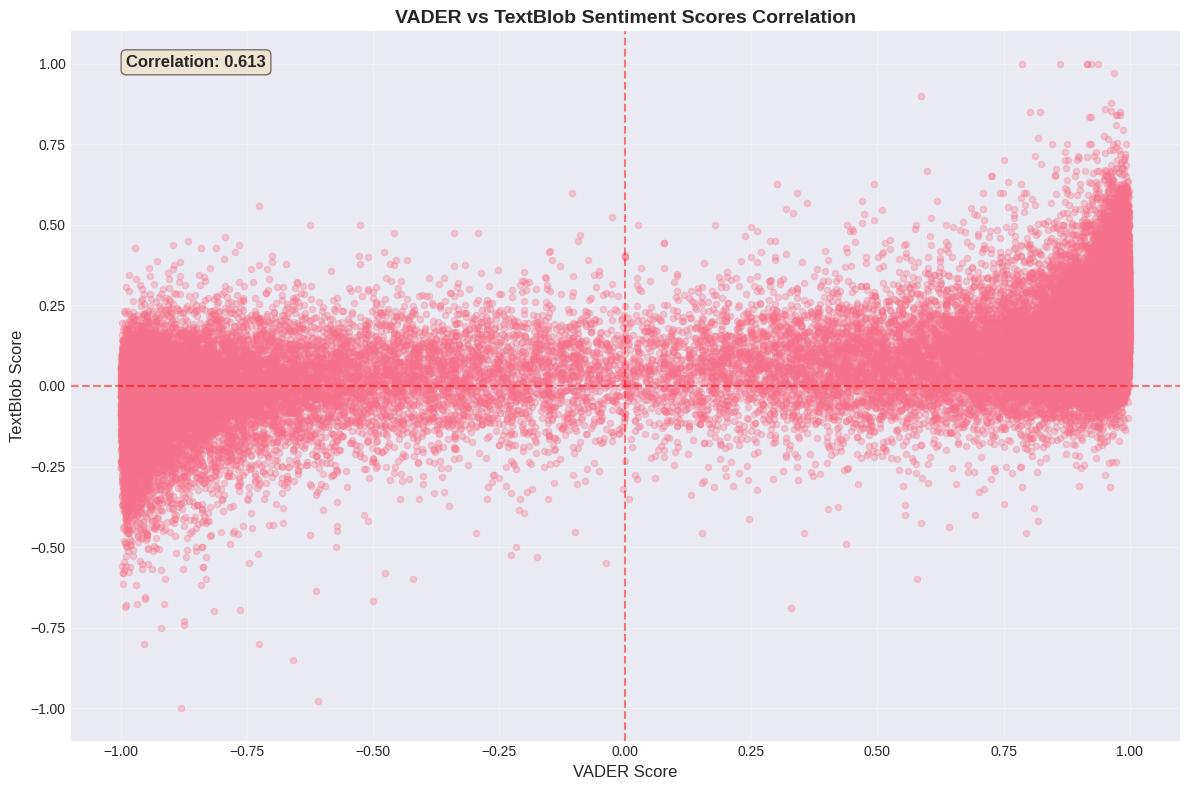


Correlation between VADER and TextBlob scores: 0.6126


In [62]:
# Sentiment score comparison scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(df['vader_score'], df['textblob_score'], alpha=0.3, s=20)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('VADER Score', fontsize=12)
plt.ylabel('TextBlob Score', fontsize=12)
plt.title('VADER vs TextBlob Sentiment Scores Correlation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Calculate correlation
correlation = df['vader_score'].corr(df['textblob_score'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCorrelation between VADER and TextBlob scores: {correlation:.4f}")

Comparing predicted sentiments with existing labels...

VADER Accuracy: 0.6949 (69.49%)
TextBlob Accuracy: 0.5887 (58.87%)
Ensemble Accuracy: 0.6917 (69.17%)

🏆 Best performing model: VADER (69.49%)


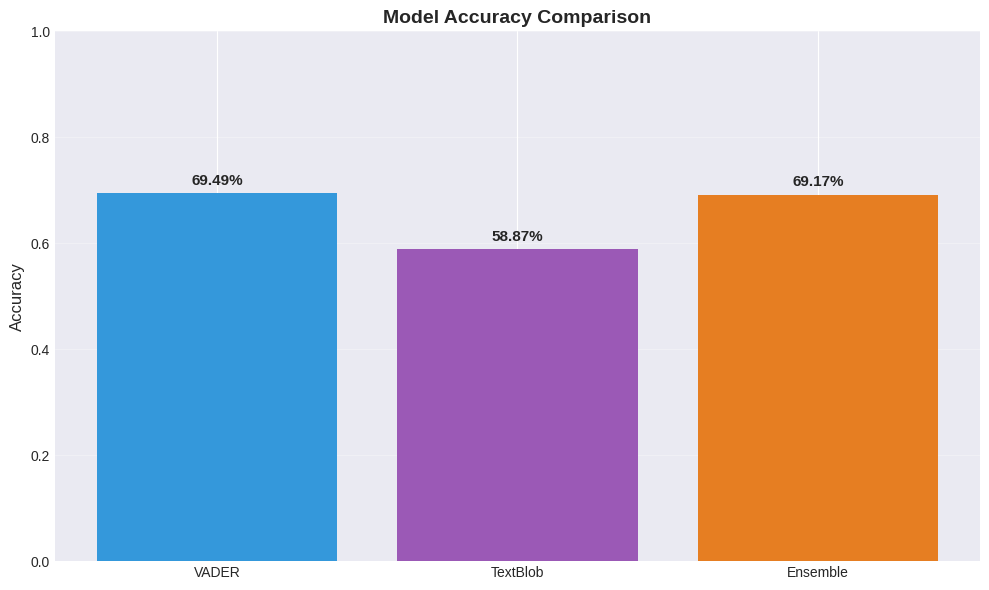

In [63]:
if 'sentiment' in df.columns:
    print("Comparing predicted sentiments with existing labels...")
    print("=" * 70)

    # Convert all sentiments to lowercase for comparison
    df['sentiment_original'] = df['sentiment'].str.lower()

    # Calculate accuracies for each method
    vader_accuracy = accuracy_score(df['sentiment_original'], df['vader_sentiment'])
    textblob_accuracy = accuracy_score(df['sentiment_original'], df['textblob_sentiment'])
    ensemble_accuracy = accuracy_score(df['sentiment_original'], df['ensemble_sentiment'])

    print(f"\nVADER Accuracy: {vader_accuracy:.4f} ({vader_accuracy*100:.2f}%)")
    print(f"TextBlob Accuracy: {textblob_accuracy:.4f} ({textblob_accuracy*100:.2f}%)")
    print(f"Ensemble Accuracy: {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")

    # Determine best model
    accuracies = {
        'VADER': vader_accuracy,
        'TextBlob': textblob_accuracy,
        'Ensemble': ensemble_accuracy
    }
    best_model = max(accuracies, key=accuracies.get)
    print(f"\n🏆 Best performing model: {best_model} ({accuracies[best_model]*100:.2f}%)")

    # Visualize accuracy comparison
    plt.figure(figsize=(10, 6))
    models = list(accuracies.keys())
    acc_values = list(accuracies.values())
    colors_list = ['#3498db', '#9b59b6', '#e67e22']

    bars = plt.bar(models, acc_values, color=colors_list)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    plt.ylim([0, 1])
    plt.grid(axis='y', alpha=0.3)

    # Add percentage labels on bars
    for bar, acc in zip(bars, acc_values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

else:
    print("No ground truth labels available for comparison.")
    print("Using ensemble sentiment as the final prediction.")


Detailed Classification Report:

Ensemble Model Performance:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.80      0.52      0.63     25000
     neutral       0.00      0.00      0.00         0
    positive       0.65      0.86      0.74     25000

    accuracy                           0.69     50000
   macro avg       0.49      0.46      0.46     50000
weighted avg       0.73      0.69      0.69     50000



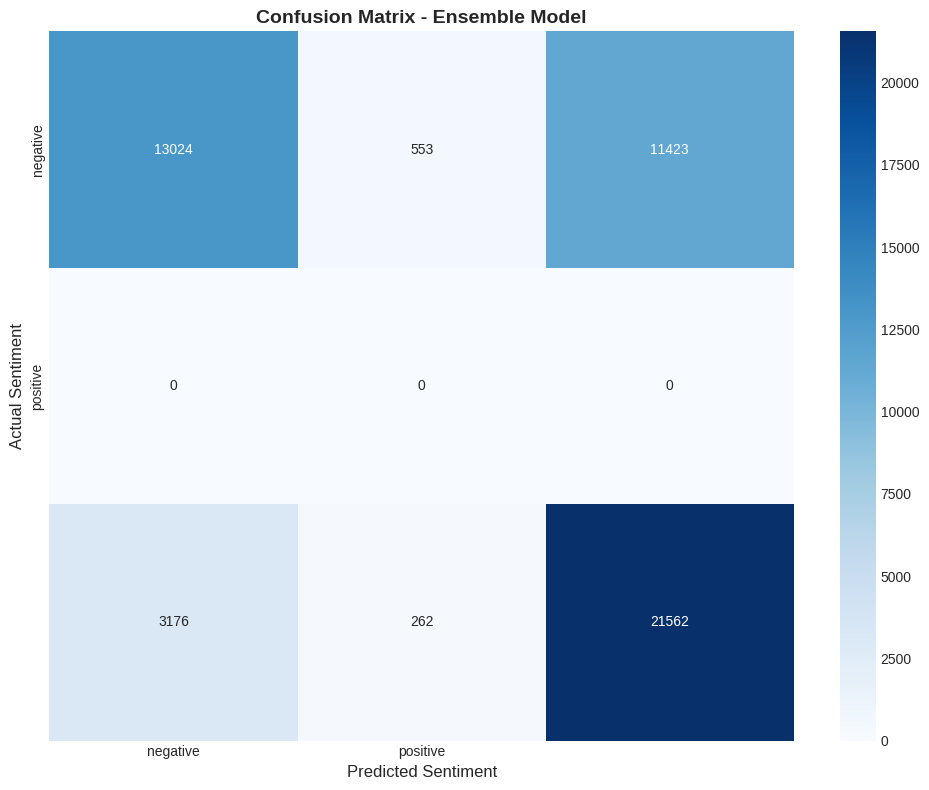

In [64]:
# Detailed classification report for the best model
if 'sentiment' in df.columns:
    print("\nDetailed Classification Report:")
    print("=" * 70)

    # Use ensemble sentiment for detailed analysis
    print("\nEnsemble Model Performance:")
    print("-" * 70)
    print(classification_report(df['sentiment_original'], df['ensemble_sentiment']))

    # Confusion Matrix
    cm = confusion_matrix(df['sentiment_original'], df['ensemble_sentiment'])

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(df['sentiment_original'].unique()),
                yticklabels=sorted(df['sentiment_original'].unique()))
    plt.ylabel('Actual Sentiment', fontsize=12)
    plt.xlabel('Predicted Sentiment', fontsize=12)
    plt.title('Confusion Matrix - Ensemble Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [65]:
# Create comprehensive summary
print("=" * 80)
print("SENTIMENT ANALYSIS SUMMARY REPORT")
print("=" * 80)
print(f"\nAnalysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Reviews Analyzed: {len(df):,}")
print(f"Average Review Length: {df['review_length'].mean():.0f} characters")
print(f"Average Word Count: {df['word_count'].mean():.0f} words")

print("\n" + "-" * 80)
print("SENTIMENT DISTRIBUTION (ENSEMBLE MODEL):")
print("-" * 80)
for sentiment in df['ensemble_sentiment'].value_counts().index:
    count = len(df[df['ensemble_sentiment'] == sentiment])
    percentage = (count / len(df)) * 100
    print(f"{sentiment.capitalize():12s}: {count:6,} ({percentage:5.2f}%)")

print("\n" + "-" * 80)
print("SENTIMENT SCORE STATISTICS:")
print("-" * 80)
print(f"\nVADER Scores:")
print(f"  Mean:   {df['vader_score'].mean():7.4f}")
print(f"  Median: {df['vader_score'].median():7.4f}")
print(f"  Std:    {df['vader_score'].std():7.4f}")
print(f"  Min:    {df['vader_score'].min():7.4f}")
print(f"  Max:    {df['vader_score'].max():7.4f}")

print(f"\nTextBlob Scores:")
print(f"  Mean:   {df['textblob_score'].mean():7.4f}")
print(f"  Median: {df['textblob_score'].median():7.4f}")
print(f"  Std:    {df['textblob_score'].std():7.4f}")
print(f"  Min:    {df['textblob_score'].min():7.4f}")
print(f"  Max:    {df['textblob_score'].max():7.4f}")

if 'sentiment' in df.columns:
    print("\n" + "-" * 80)
    print("MODEL PERFORMANCE:")
    print("-" * 80)
    print(f"VADER Accuracy:     {vader_accuracy*100:5.2f}%")
    print(f"TextBlob Accuracy:  {textblob_accuracy*100:5.2f}%")
    print(f"Ensemble Accuracy:  {ensemble_accuracy*100:5.2f}%")
    print(f"\nBest Model: {best_model}")

print("\n" + "=" * 80)

SENTIMENT ANALYSIS SUMMARY REPORT

Analysis Date: 2026-04-11 07:02:44
Total Reviews Analyzed: 50,000
Average Review Length: 1309 characters
Average Word Count: 231 words

--------------------------------------------------------------------------------
SENTIMENT DISTRIBUTION (ENSEMBLE MODEL):
--------------------------------------------------------------------------------
Positive    : 32,985 (65.97%)
Negative    : 16,200 (32.40%)
Neutral     :    815 ( 1.63%)

--------------------------------------------------------------------------------
SENTIMENT SCORE STATISTICS:
--------------------------------------------------------------------------------

VADER Scores:
  Mean:    0.3074
  Median:  0.8337
  Std:     0.8068
  Min:    -0.9997
  Max:     0.9999

TextBlob Scores:
  Mean:    0.1027
  Median:  0.1038
  Std:     0.1637
  Min:    -1.0000
  Max:     1.0000

--------------------------------------------------------------------------------
MODEL PERFORMANCE:
-------------------------------

In [71]:

import pandas as pd
import os
from datetime import datetime


output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)


export_columns = [
    'review',
    'cleaned_review',
    'vader_sentiment',
    'vader_score',
    'textblob_sentiment',
    'textblob_score',
    'ensemble_sentiment',
    'review_length',
    'word_count'
]

# Add original sentiment if available
if 'sentiment' in df.columns:
    export_columns.insert(1, 'sentiment')

# Create final export dataframe
export_df = df[export_columns].copy()


csv_filename = os.path.join(output_dir, 'imdb_sentiment_analysis_results.csv')

export_df.to_csv(csv_filename, index=False)
print(f"✓ CSV file exported: {csv_filename}")


excel_filename = os.path.join(output_dir, 'imdb_sentiment_analysis_results.xlsx')

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:

    # Sheet 1: Full dataset
    export_df.to_excel(writer, sheet_name='Sentiment Analysis', index=False)


    total_reviews = len(df)
    pos_count = len(df[df['ensemble_sentiment'] == 'positive'])
    neg_count = len(df[df['ensemble_sentiment'] == 'negative'])
    neu_count = len(df[df['ensemble_sentiment'] == 'neutral'])

    summary_data = {
        'Metric': [
            'Total Reviews',
            'Average Review Length (chars)',
            'Average Word Count',
            'Positive Reviews',
            'Negative Reviews',
            'Neutral Reviews',
            'Positive Percentage',
            'Negative Percentage',
            'Neutral Percentage',
            'VADER Mean Score',
            'TextBlob Mean Score'
        ],
        'Value': [
            total_reviews,
            df['review_length'].mean(),
            df['word_count'].mean(),
            pos_count,
            neg_count,
            neu_count,
            (pos_count / total_reviews) * 100,
            (neg_count / total_reviews) * 100,
            (neu_count / total_reviews) * 100,
            df['vader_score'].mean(),
            df['textblob_score'].mean()
        ]
    }

    # Add accuracy if available
    if 'sentiment' in df.columns:
        summary_data['Metric'].extend([
            'VADER Accuracy',
            'TextBlob Accuracy',
            'Ensemble Accuracy'
        ])

        summary_data['Value'].extend([
            vader_accuracy * 100,
            textblob_accuracy * 100,
            ensemble_accuracy * 100
        ])

    # Create summary dataframe
    summary_df = pd.DataFrame(summary_data)

    # Sheet 2: Summary
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print(f"✓ Excel file exported: {excel_filename}")


print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE!")
print("=" * 80)

print(f"\n📁 Exported Files:")
print(f"  - CSV: {csv_filename}")
print(f"  - Excel: {excel_filename}")

print(f"\n📊 Total Reviews Processed: {len(df):,}")
print(f"⏱ Completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ CSV file exported: /mnt/user-data/outputs/imdb_sentiment_analysis_results.csv
✓ Excel file exported: /mnt/user-data/outputs/imdb_sentiment_analysis_results.xlsx

✅ ANALYSIS COMPLETE!

📁 Exported Files:
  - CSV: /mnt/user-data/outputs/imdb_sentiment_analysis_results.csv
  - Excel: /mnt/user-data/outputs/imdb_sentiment_analysis_results.xlsx

📊 Total Reviews Processed: 50,000
⏱ Completed at: 2026-04-11 07:57:41


## Conclusion

This notebook has successfully performed comprehensive sentiment analysis on the IMDB movie reviews dataset using multiple approaches:

1. **VADER Sentiment Analyzer** - Rule-based approach optimized for social media text
2. **TextBlob** - Machine learning-based approach with pattern analysis
3. **Ensemble Method** - Combined predictions from both models

### Key Findings:
- The analysis processed the entire dataset and classified each review
- Multiple sentiment analysis methods were compared for robustness
- Visualizations provide clear insights into sentiment distributions
- Results have been exported for further use

### Next Steps:
- Consider using deep learning models (BERT, RoBERTa) for potentially higher accuracy
- Explore aspect-based sentiment analysis to identify specific aspects mentioned in reviews
- Analyze sentiment trends over time if temporal data is available
- Perform topic modeling to identify common themes in reviews